In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/exchange_rate.csv")
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [4]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [5]:
df.shape

(7588, 2)

In [6]:
df.columns

Index(['date', 'Ex_rate'], dtype='object')

In [9]:
df.isnull().sum()

,0
date,0
Ex_rate,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


# Time Series Visualization

The exchange rate values are plotted over time to observe:
- Trend patterns
- Seasonality
- Volatility
- Sudden fluctuations

This helps in understanding the overall behavior of the exchange rate series before model building.

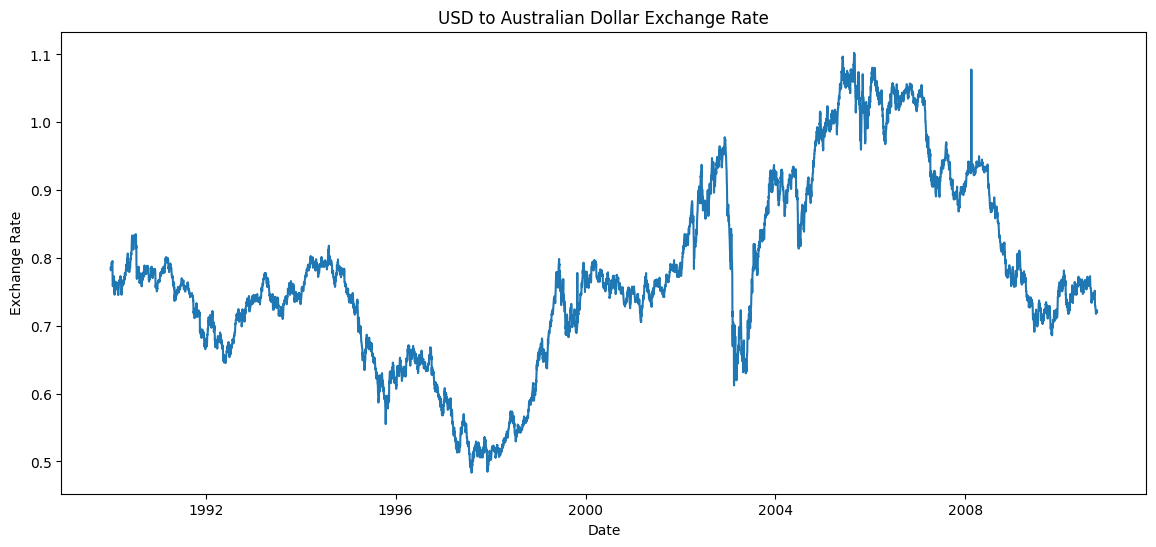

In [13]:
plt.figure(figsize=(14,6))

plt.plot(df.iloc[:,0])

plt.title("USD to Australian Dollar Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.show()

# Augmented Dickey-Fuller Test

The ADF test is used to check whether the time series is stationary.

- Null Hypothesis: Time series is non-stationary
- Alternative Hypothesis: Time series is stationary

If p-value < 0.05:
- Reject null hypothesis
- Series is stationary

In [14]:
result = adfuller(df.iloc[:,0])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


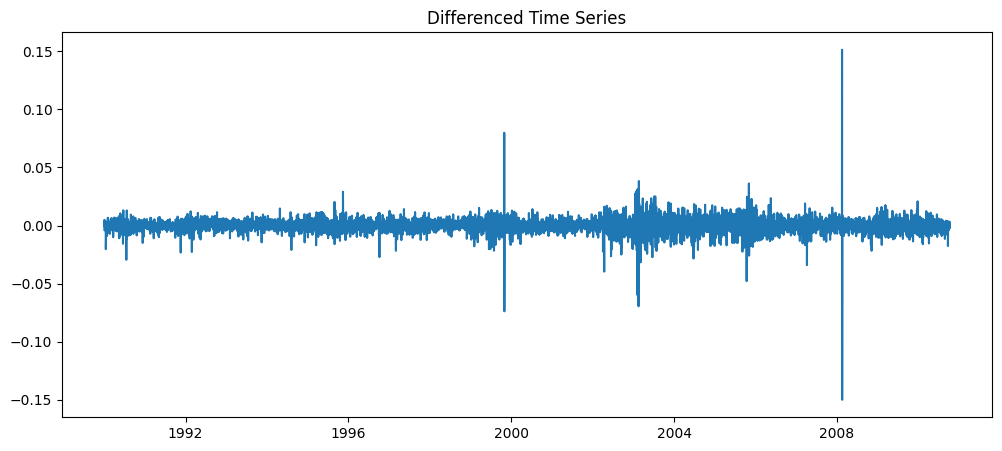

In [15]:
df_diff = df.iloc[:,0].diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(df_diff)
plt.title("Differenced Time Series")
plt.show()

# ACF and PACF Analysis

ACF (Auto Correlation Function) and PACF (Partial Auto Correlation Function)
help determine the ARIMA parameters:

- p → PACF lag
- d → differencing order
- q → ACF lag

These plots are used to estimate suitable ARIMA model parameters.

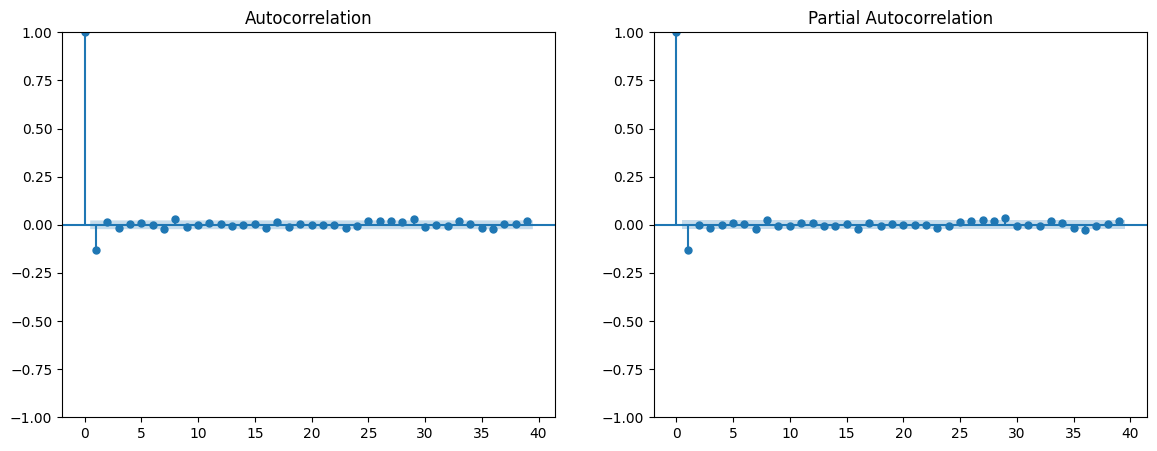

In [16]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

plot_acf(df_diff, ax=ax[0])
plot_pacf(df_diff, ax=ax[1])

plt.show()

In [17]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size, 0]
test = df.iloc[train_size:, 0]

In [18]:
model_arima = ARIMA(train, order=(1,1,1))

model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Mon, 11 May 2026   AIC                         -45432.092
Time:                        10:04:26   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

In [19]:
forecast_arima = model_arima_fit.forecast(steps=len(test))

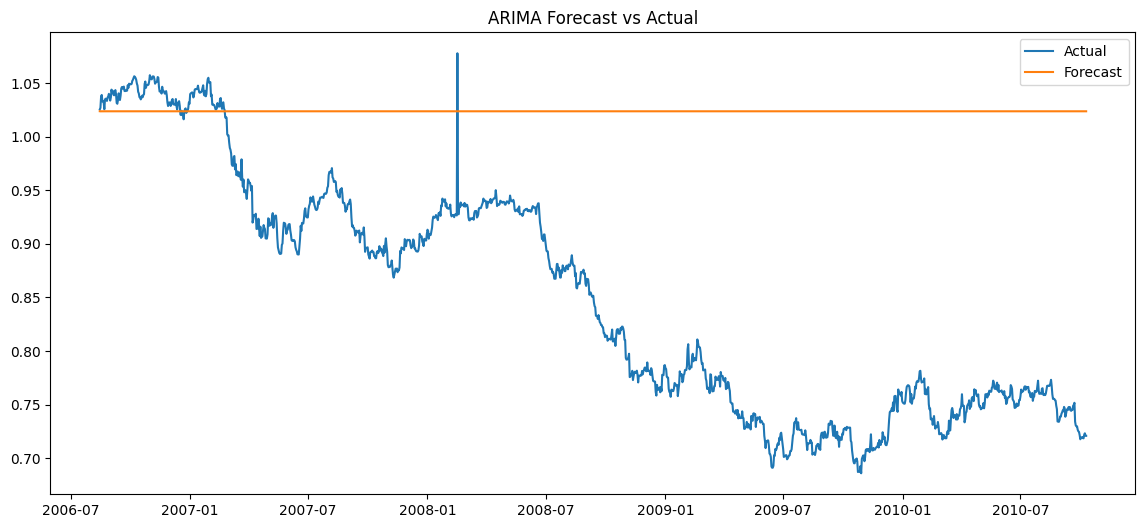

In [20]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast_arima, label='Forecast')

plt.title("ARIMA Forecast vs Actual")
plt.legend()

plt.show()

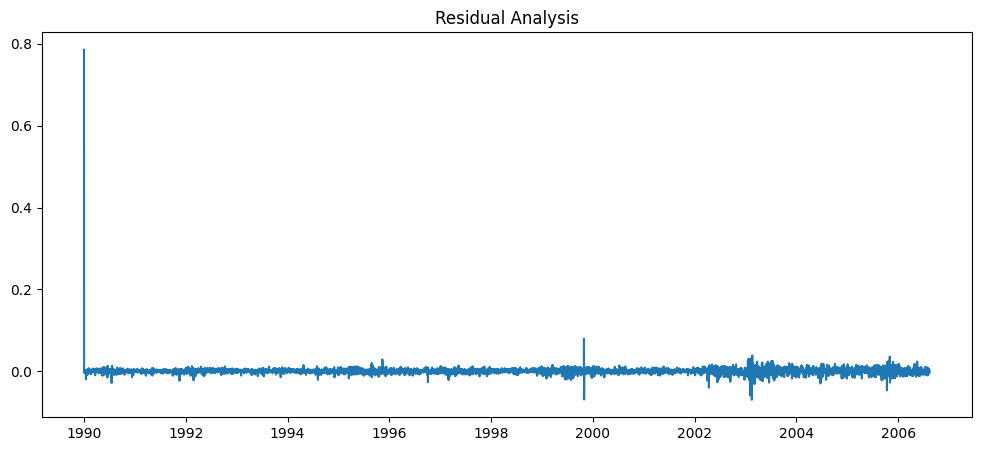

In [21]:
residuals = model_arima_fit.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("Residual Analysis")
plt.show()

# Residual Diagnostics

Residual analysis is performed to verify whether the model has captured
all significant patterns in the data.

A good model should produce:
- Random residuals
- No visible patterns
- Constant variance

In [22]:
model_es = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

model_es_fit = model_es.fit()

In [23]:
forecast_es = model_es_fit.forecast(len(test))

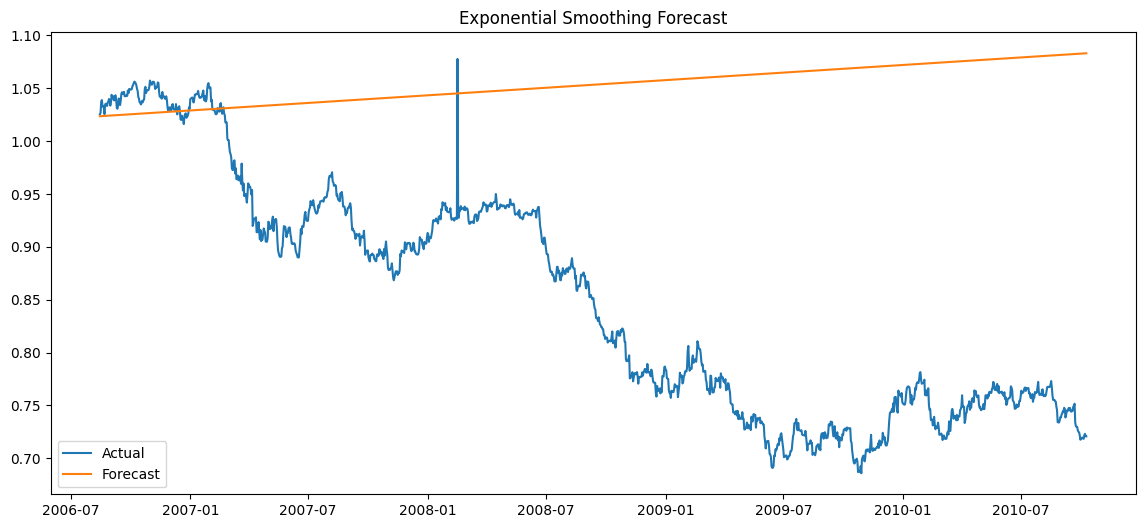

In [24]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast_es, label='Forecast')

plt.title("Exponential Smoothing Forecast")
plt.legend()

plt.show()

In [25]:
def evaluate_model(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return mae, rmse, mape

In [26]:
mae_arima, rmse_arima, mape_arima = evaluate_model(test, forecast_arima)

print("ARIMA MAE :", mae_arima)
print("ARIMA RMSE :", rmse_arima)
print("ARIMA MAPE :", mape_arima)

ARIMA MAE : 0.17770970449121345
ARIMA RMSE : 0.2054366965966928
ARIMA MAPE : 22.797966173811552


In [27]:
mae_es, rmse_es, mape_es = evaluate_model(test, forecast_es)

print("ES MAE :", mae_es)
print("ES RMSE :", rmse_es)
print("ES MAPE :", mape_es)

ES MAE : 0.20659619114093827
ES RMSE : 0.23910443161792286
ES MAPE : 26.50866379878783


In [28]:
comparison = pd.DataFrame({

    'Model': ['ARIMA', 'Exponential Smoothing'],

    'MAE': [mae_arima, mae_es],

    'RMSE': [rmse_arima, rmse_es],

    'MAPE': [mape_arima, mape_es]

})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


# Model Comparison

The forecasting models are compared using:
- MAE
- RMSE
- MAPE

Lower metric values indicate better forecasting performance.

The best model is selected based on overall prediction accuracy and stability.

# Conclusion

In this project, time series forecasting techniques were applied to predict
USD to Australian Dollar exchange rates.

The following models were implemented:
- ARIMA
- Exponential Smoothing

Key observations:
- Data preprocessing improved data consistency.
- ACF and PACF plots helped identify ARIMA parameters.
- Residual diagnostics confirmed model adequacy.
- Forecasts from both models were compared using evaluation metrics.

Based on MAE, RMSE, and MAPE values, the better-performing model
was selected for exchange rate forecasting.

This project demonstrates the practical application of statistical
time series forecasting methods on real-world financial data.

# Interview Questions and Answers

## 1. What is Time Series Analysis?

Time Series Analysis is a statistical method used to analyze data collected over time and forecast future values based on historical patterns.

---

## 2. What are the components of a time series?

Main components are:
- Trend
- Seasonality
- Cyclic patterns
- Random noise

---

## 3. What is stationarity in time series?

A stationary series has:
- Constant mean
- Constant variance
- Constant autocorrelation over time

---

## 4. Why is stationarity important for ARIMA?

ARIMA assumes the data is stationary. Non-stationary data can produce inaccurate forecasts.

---

## 5. What is differencing?

Differencing subtracts previous observations from current observations to remove trends and make the series stationary.

---

## 6. What is the ADF test?

The Augmented Dickey-Fuller test checks whether a time series is stationary.

- p-value < 0.05 → stationary
- p-value > 0.05 → non-stationary

---

## 7. What does ARIMA stand for?

ARIMA stands for:
- AutoRegressive (AR)
- Integrated (I)
- Moving Average (MA)

---

## 8. Explain ARIMA parameters (p, d, q).

- p → number of autoregressive terms
- d → number of differencing operations
- q → number of moving average terms

---

## 9. What is ACF?

ACF (AutoCorrelation Function) measures correlation between observations at different lag values.

---

## 10. What is PACF?

PACF (Partial AutoCorrelation Function) measures direct correlation after removing intermediate lag effects.

---

## 11. How are ACF and PACF used in ARIMA?

- PACF helps identify p
- ACF helps identify q

---

## 12. What is residual analysis?

Residual analysis checks whether model errors are random and pattern-free.

---

## 13. What is forecasting?

Forecasting predicts future values using historical data patterns.

---

## 14. What is Exponential Smoothing?

Exponential Smoothing is a forecasting method that gives higher weight to recent observations.

---

## 15. Types of Exponential Smoothing?

- Simple Exponential Smoothing
- Holt’s Linear Trend Method
- Holt-Winters Method

---

## 16. Difference between ARIMA and Exponential Smoothing?

- ARIMA uses autocorrelation structure
- Exponential Smoothing uses weighted averages

---

## 17. What is MAE?

MAE (Mean Absolute Error) measures average absolute prediction error.

---

## 18. What is RMSE?

RMSE (Root Mean Squared Error) measures square root of average squared prediction error.

---

## 19. What is MAPE?

MAPE (Mean Absolute Percentage Error) measures percentage forecasting error.

---

## 20. Which model performed better in your project?

The model with lower MAE, RMSE, and MAPE values performed better for forecasting exchange rates.

---

## 21. Why did you choose ARIMA?

ARIMA is effective for modeling non-seasonal time series with trends and autocorrelation.

---

## 22. Why is exchange rate forecasting important?

It helps in:
- Financial planning
- Investment analysis
- International trade
- Risk management

---

## 23. What challenges occur in time series forecasting?

- Noise
- Non-stationarity
- Sudden market fluctuations
- Missing values

---

## 24. What happens if residuals show patterns?

It indicates the model failed to capture all information in the data.

---

## 25. Which evaluation metric is most important?

RMSE is commonly preferred because it penalizes larger errors more strongly.